In [96]:
import pandas as pd
from FLAI import data, causal_graph
# from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
# import shap
import matplotlib.pyplot as plt

import dutils

In [76]:
# df = pd.read_csv("dutch.csv")  
# df = preprocess_law_school(df, bins=10)

In [98]:
# 📦 4. Filter Relevant Columns

dt = dutils.loader("law_school_clean.csv")

#######

# import pandas as pd
# import numpy as np

# # Convert to DataFrame
# df = pd.DataFrame(dt.data, columns=dt.variables)

# # Ensure numeric types
# for col in ['juv_fel_count', 'juv_misd_count', 'juv_other_count']:
#     df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# # Compute juv_crime
# df['juv_crime'] = df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count']

# # Select only the relevant features
# selected_cols = [
#     'race', 'sex', 'two_year_recid', 'score_text', 'priors_count',
#     'age_cat', 'v_score_text', 'juv_crime', 'c_charge_degree'
# ]
# df = df[selected_cols].copy()

# # Assign back to dt
# dt.data = df.values
# dt.variables = df.columns.tolist()
# dt.arity = np.array([len(df[col].unique()) for col in df.columns])

########

dt.quantize_all()

df_q = pd.DataFrame(dt.data.astype(int), columns=dt.variables)

flai_dataset = data.Data(df_q, transform=False)

print("Shape:", flai_dataset.data.shape)
print("\nDtypes after transform=False:\n", flai_dataset.data.dtypes)

# Peek at first rows
print("\nHead of transformed data:\n", flai_dataset.data.head())

for col in flai_dataset.data.columns:
    print(col, sorted(flai_dataset.data[col].unique()))


Not an int
Not an int
Not an int
Not an int
Not an int
Not an int
Not an int
Not an int
Not an int
Not an int
Not an int
Falling back to searchsorted for conversion
Not an int
[4.0, 7.0] 0
[4.0, 7.0] 0
[35.0, 39.0] 0
[3.1, 3.4] 0
[-0.32, 0.51] 0
[-0.43, 0.47] 0
[4.0] 1
Shape: (20798, 12)

Dtypes after transform=False:
 decile1b    int64
decile3     int64
lsat        int64
ugpa        int64
zfygpa      int64
zgpa        int64
fulltime    int64
fam_inc     int64
male        int64
tier        int64
race        int64
pass_bar    int64
dtype: object

Head of transformed data:
    decile1b  decile3  lsat  ugpa  zfygpa  zgpa  fulltime  fam_inc  male  tier  \
0         2        2     2     2       2     2         0        4     0     1   
1         1        0     0     2       1     0         0        3     0     1   
2         2        1     1     1       2     1         0        2     1     1   
3         2        1     2     1       2     1         0        3     0     1   
4         0     

In [100]:
# 🔍 4. Fairness Diagnostic - Equity, Equality, Fairness
df_fair, _ = flai_dataset.fairness_eqa_eqi( 
    features=['pass_bar'],
    target_column='pass_bar',
    column_filter=['male', 'race'], 
    plot=False
)

fulltime
fam_inc
male


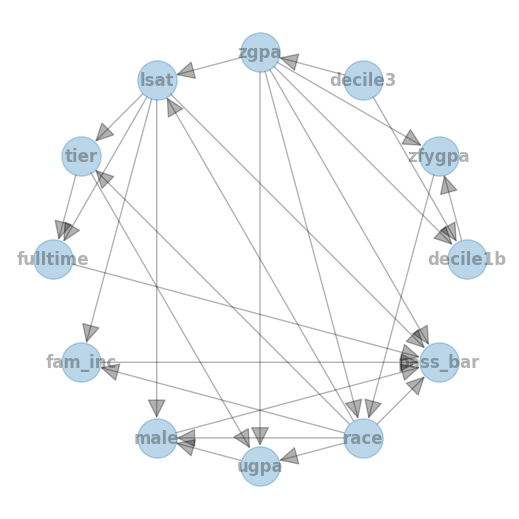

In [102]:
# 🧠 5. Create Causal Graph & Mitigate Bias
flai_graph = causal_graph.CausalGraph(flai_dataset, target='pass_bar')
flai_graph.plot(directed=True)

In [104]:
# ✂️ Mitigate Relations and CPDs
flai_graph.mitigate_edge_relation(sensible_feature=['male', 'race'])


[('decile1b', 'zfygpa'),
 ('decile3', 'zgpa'),
 ('decile3', 'decile1b'),
 ('lsat', 'tier'),
 ('lsat', 'fulltime'),
 ('lsat', 'fam_inc'),
 ('zgpa', 'decile1b'),
 ('zgpa', 'pass_bar'),
 ('zgpa', 'ugpa'),
 ('zgpa', 'zfygpa'),
 ('zgpa', 'lsat'),
 ('tier', 'ugpa'),
 ('tier', 'fulltime'),
 ('race', 'lsat'),
 ('race', 'fam_inc'),
 ('race', 'tier'),
 ('race', 'ugpa'),
 ('race', 'pass_bar'),
 ('lsat', 'pass_bar'),
 ('fulltime', 'pass_bar'),
 ('fam_inc', 'pass_bar'),
 ('male', 'pass_bar'),
 ('ugpa', 'pass_bar'),
 ('zfygpa', 'lsat'),
 ('zfygpa', 'fam_inc'),
 ('zfygpa', 'tier'),
 ('zfygpa', 'ugpa'),
 ('zfygpa', 'pass_bar'),
 ('zgpa', 'fam_inc'),
 ('zgpa', 'tier')]

In [106]:
flai_graph.mitigate_calculation_cpd(sensible_feature=['male', 'race'])

In [108]:
from pgmpy.estimators import BayesianEstimator

model = flai_graph.graph["model"]
model.fit(
    flai_dataset.data,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=1
)

In [110]:
# --- Debug invalid CPDs before sampling ---
model = flai_graph.graph['model']   # pgmpy BayesianModel object
bad = []
for cpd in model.get_cpds():
    if not cpd.is_valid_cpd():
        bad.append(cpd.variable)
        print("INVALID CPD:", cpd.variable)
        print(cpd)

if bad:
    var = bad[0]
    parents = model.get_parents(var)
    print("\nParents of", var, ":", parents)

    df_dbg = flai_dataset.data
    cols = parents + [var]
    g = df_dbg[cols].astype(str).groupby(cols).size().unstack(fill_value=0)
    print("\nCounts per parent config × states of", var, ":\n", g.head(20))


In [112]:
fair_data = flai_graph.generate_dataset(n_samples=10000, methodtype='bayes')


In [114]:
fair_data.data.to_csv("Law-Flai-new-synthetic_fair_data.csv", index=False)

In [ ]:
# 🤖 7. Train Model with Fair Data
# X = fair_data.data[['priors_count', 'age_cat', 'score_text', 'v_score_text', 'c_charge_degree', 'juv_crime']]
# y = fair_data.data['two_year_recid']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=42)

# model = XGBClassifier()
# model.fit(X_train, y_train)

In [ ]:
# 🧠 8. SHAP Analysis
# explainer = shap.Explainer(model)
# shap_values = explainer(X_test)

# shap.plots.beeswarm(shap_values)
# shap.plots.bar(shap_values)

In [ ]:
# 📊 9. Evaluate Fairness Metrics
# fair_data.data["Predicted"] = model.predict(X)

# metrics = fair_data.fairness_metrics(
#     target_column='two_year_recid',
#     predicted_column='Predicted',
#     columns_fair={
#         'sex': {'privileged': 1, 'unprivileged': 0},
#         'race': {'privileged': 1, 'unprivileged': 0}
#     }
# )

# print("Sex Fairness:", metrics['sex'])
# print("Race Fairness:", metrics['race'])


In [3]:
!pip install flai-causal